In [1]:
import pandas as pd

Read the files

In [2]:
policy = pd.read_csv("C:\\Class\\Practice\\Project\\Insurance_Risk_Scoring\\Dataset\\freMTPL2freq.csv")
claims = pd.read_csv("C:\\Class\\Practice\\Project\\Insurance_Risk_Scoring\\Dataset\\freMTPL2sev.csv")

In [3]:
print(policy.columns)
print(claims.columns)

Index(['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region'],
      dtype='object')
Index(['IDpol', 'ClaimAmount'], dtype='object')


Aggregate claims at policy level

In [4]:
claims_agg = (
    claims
    .groupby("IDpol")
    .agg(
        claim_count=("ClaimAmount", "count"),
        total_claim_amount=("ClaimAmount", "sum")
    )
    .reset_index()
)

Merge aggregated claims with policy data

In [5]:
#Left Join
data = policy.merge(
    claims_agg,
    on="IDpol",
    how="left"
)

In [6]:
data

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,claim_count,total_claim_amount
0,1.0,1,0.10000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,NaN,NaN
1,3.0,1,0.77000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,NaN,NaN
2,5.0,1,0.75000,6,2,52,50,B12,Diesel,B,54,Picardie,NaN,NaN
3,10.0,1,0.09000,7,0,46,50,B12,Diesel,B,76,Aquitaine,NaN,NaN
4,11.0,1,0.84000,7,0,46,50,B12,Diesel,B,76,Aquitaine,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678008,6114326.0,0,0.00274,4,0,54,50,B12,Regular,E,3317,Provence-Alpes-Cotes-D'Azur,NaN,NaN
678009,6114327.0,0,0.00274,4,0,41,95,B12,Regular,E,9850,Ile-de-France,NaN,NaN
678010,6114328.0,0,0.00274,6,2,45,50,B12,Diesel,D,1323,Rhone-Alpes,NaN,NaN
678011,6114329.0,0,0.00274,4,0,60,50,B12,Regular,B,95,Bourgogne,NaN,NaN


Fix missing claim values

In [7]:
data["claim_count"] = data["claim_count"].fillna(0)
data["total_claim_amount"] = data["total_claim_amount"].fillna(0)

In [8]:
data

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,claim_count,total_claim_amount
0,1.0,1,0.10000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0.0
1,3.0,1,0.77000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0.0
2,5.0,1,0.75000,6,2,52,50,B12,Diesel,B,54,Picardie,0.0,0.0
3,10.0,1,0.09000,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0.0
4,11.0,1,0.84000,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678008,6114326.0,0,0.00274,4,0,54,50,B12,Regular,E,3317,Provence-Alpes-Cotes-D'Azur,0.0,0.0
678009,6114327.0,0,0.00274,4,0,41,95,B12,Regular,E,9850,Ile-de-France,0.0,0.0
678010,6114328.0,0,0.00274,6,2,45,50,B12,Diesel,D,1323,Rhone-Alpes,0.0,0.0
678011,6114329.0,0,0.00274,4,0,60,50,B12,Regular,B,95,Bourgogne,0.0,0.0


DATA VALIDATION

In [9]:
data["Exposure"].describe()

count    678013.000000
mean          0.528750
std           0.364442
min           0.002732
25%           0.180000
50%           0.490000
75%           0.990000
max           2.010000
Name: Exposure, dtype: float64

In [10]:
data=data[data["Exposure"]>0]

In [11]:
data["Has_Claim"]=(data["claim_count"]>0).astype(int)

In [12]:
data["severity"] = data["total_claim_amount"] / data["claim_count"]
data.loc[data["claim_count"] == 0, "severity"] = 0

In [13]:
data["Has_Claim"].value_counts(normalize=True)

Has_Claim
0    0.96321
1    0.03679
Name: proportion, dtype: float64

In [14]:
data["claim_count"].describe()

count    678013.000000
mean          0.039002
std           0.207166
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          16.000000
Name: claim_count, dtype: float64

In [15]:
data["total_claim_amount"].describe()

count    6.780130e+05
mean     8.835998e+01
std      5.822454e+03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.075401e+06
Name: total_claim_amount, dtype: float64

In [16]:
cap = data["total_claim_amount"].quantile(0.99)
data["total_claim_amount"] = data["total_claim_amount"].clip(upper=cap)

In [17]:
import numpy as np
data["log_total_claim_amount"] = np.log1p(data["total_claim_amount"])

In [18]:
total_exposure = data["Exposure"].sum()
total_claims = data["claim_count"].sum()
total_loss = data["total_claim_amount"].sum()

claim_frequency = total_claims / total_exposure
avg_severity = total_loss / total_claims

claim_frequency, avg_severity

(np.float64(0.07376301507498409), np.float64(913.3859670549085))

DATA CLEANING (INSURANCE-GRADE)

In [19]:
DROP_COLS = [
    "IDpol",                 # policy identifier
    "Has_Claim",             # diagnostic only
    "severity",              # derived target
    "total_claim_amount"     # target component
]

data_model = data.drop(columns=DROP_COLS)

In [20]:
num_cols = data_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = data_model.select_dtypes(include=["object"]).columns.tolist()

num_cols, cat_cols

(['ClaimNb',
  'Exposure',
  'VehPower',
  'VehAge',
  'DrivAge',
  'BonusMalus',
  'Density',
  'claim_count',
  'log_total_claim_amount'],
 ['VehBrand', 'VehGas', 'Area', 'Region'])

In [21]:
for col in num_cols:
    data_model[col] = data_model[col].fillna(data_model[col].median())

In [22]:
for col in cat_cols:
    data_model[col] = data_model[col].fillna("Unknown")

In [23]:
data_model[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ClaimNb,678013.0,0.053247,0.240117,0.000000,0.00,0.00,0.00,16.000000
Exposure,678013.0,0.528750,0.364442,0.002732,0.18,0.49,0.99,2.010000
VehPower,678013.0,6.454631,2.050906,4.000000,5.00,6.00,7.00,15.000000
VehAge,678013.0,7.044265,5.666232,0.000000,2.00,6.00,11.00,100.000000
DrivAge,678013.0,45.499122,14.137444,18.000000,34.00,44.00,55.00,100.000000
BonusMalus,678013.0,59.761502,15.636658,50.000000,50.00,50.00,64.00,230.000000
Density,678013.0,1792.422405,3958.646564,1.000000,92.00,393.00,1658.00,27000.000000
claim_count,678013.0,0.039002,0.207166,0.000000,0.00,0.00,0.00,16.000000
log_total_claim_amount,678013.0,0.245208,1.265469,0.000000,0.00,0.00,0.00,7.134356


In [24]:
for col in cat_cols:
    print(col, data_model[col].nunique())

VehBrand 11
VehGas 2
Area 6
Region 21


In [25]:
freq = data_model["Area"].value_counts(normalize=True)
rare = freq[freq < 0.01].index

data_model["Area_grouped"] = data_model["Area"].replace(rare, "Other")
data_model = data_model.drop(columns=["Area"])

In [26]:
import numpy as np
data_model["log_VehPower"] = np.log1p(data_model["VehPower"])

In [27]:
data_model = data_model.drop(columns=["VehPower"])

In [28]:
data_model["DrivAgeBand"] = pd.cut(
    data_model["DrivAge"],
    bins=[0, 25, 40, 100],
    labels=["<25", "25-40", "40+"]
)

In [29]:
cat_cols = data_model.select_dtypes(include=["object"]).columns.tolist()
cat_cols

['VehBrand', 'VehGas', 'Region', 'Area_grouped']

In [30]:
data_model = pd.get_dummies(
    data_model,
    columns=cat_cols + ["DrivAgeBand"],
    drop_first=True
)

In [31]:
data_model.isna().sum().sum()

np.int64(0)

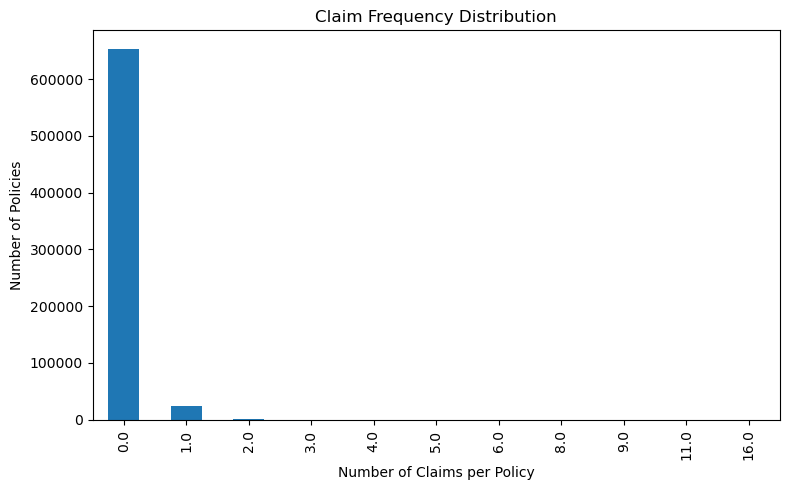

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
data["claim_count"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Number of Claims per Policy")
plt.ylabel("Number of Policies")
plt.title("Claim Frequency Distribution")

plt.tight_layout()
plt.savefig("./images/frequency_distribution.png", dpi=300)
plt.show()

RISK EDA

In [33]:
data["frequency"] = data["claim_count"] / data["Exposure"]

data["severity"] = 0
mask = data["claim_count"] > 0
data.loc[mask, "severity"] = (
    data.loc[mask, "total_claim_amount"] / data.loc[mask, "claim_count"]
)

data["pure_premium"] = data["frequency"] * data["severity"]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18936\432909668.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 303.     1253.3288 1253.3288 ... 1253.3288  626.6644 1253.3288]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[mask, "severity"] = (


In [34]:
data[["frequency", "severity", "pure_premium"]].describe()

,frequency,severity,pure_premium
count,678013.000000,678013.000000,678013.000000
mean,0.118625,34.374660,111.608534
std,2.024549,191.610536,2094.760229
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,365.000004,1253.328800,439460.004395


In [35]:
data["DrivAgeBand"] = pd.cut(
    data["DrivAge"],
    bins=[0, 25, 40, 60, 100],
    labels=["<25", "25-40", "40-60", "60+"]
)

In [36]:
age_risk = (
    data
    .groupby("DrivAgeBand")
    .agg(
        exposure=("Exposure", "sum"),
        claims=("claim_count", "sum"),
        total_loss=("total_claim_amount", "sum")
    )
)

age_risk["frequency"] = age_risk["claims"] / age_risk["exposure"]
age_risk["severity"] = age_risk["total_loss"] / age_risk["claims"]
age_risk["pure_premium"] = age_risk["frequency"] * age_risk["severity"]

age_risk

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18936\1816354486.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("DrivAgeBand")


,exposure,claims,total_loss,frequency,severity,pure_premium
DrivAgeBand,,,,,,
<25,16227.903263,2403.0,2.159878e+06,0.148078,898.825736,133.096569
25-40,113117.532830,8179.0,7.323110e+06,0.072305,895.355129,64.738944
40-60,163865.946213,11893.0,1.089490e+07,0.072578,916.077054,66.486690
60+,65288.063157,3969.0,3.775686e+06,0.060792,951.294095,57.831188


In [37]:
veh_risk = (
    data
    .groupby(pd.cut(data["VehAge"], bins=[0, 5, 10, 20, 50]))
    .agg(
        exposure=("Exposure", "sum"),
        claims=("claim_count", "sum"),
        total_loss=("total_claim_amount", "sum")
    )
)

veh_risk["frequency"] = veh_risk["claims"] / veh_risk["exposure"]
veh_risk["severity"] = veh_risk["total_loss"] / veh_risk["claims"]
veh_risk["pure_premium"] = veh_risk["frequency"] * veh_risk["severity"]

veh_risk

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18936\154782229.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(pd.cut(data["VehAge"], bins=[0, 5, 10, 20, 50]))


,exposure,claims,total_loss,frequency,severity,pure_premium
VehAge,,,,,,
"(0, 5]",134497.150395,9910.0,9.088117e+06,0.073682,917.065287,67.571075
"(5, 10]",99008.916360,8009.0,7.259675e+06,0.080892,906.439609,73.323445
"(10, 20]",103127.134014,7137.0,6.522406e+06,0.069206,913.886201,63.246263
"(20, 50]",5093.010500,204.0,1.911786e+05,0.040055,937.150200,37.537453


In [38]:
area_risk = (
    data
    .groupby("Area")
    .agg(
        exposure=("Exposure", "sum"),
        claims=("claim_count", "sum"),
        total_loss=("total_claim_amount", "sum")
    )
)

area_risk["frequency"] = area_risk["claims"] / area_risk["exposure"]
area_risk["severity"] = area_risk["total_loss"] / area_risk["claims"]
area_risk["pure_premium"] = area_risk["frequency"] * area_risk["severity"]

area_risk.sort_values("pure_premium", ascending=False)

,exposure,claims,total_loss,frequency,severity,pure_premium
Area,,,,,,
E,63819.314270,6122.0,5.506520e+06,0.095927,899.464254,86.282973
F,8129.234074,774.0,6.837449e+05,0.095212,883.391402,84.109393
D,77120.191692,6458.0,5.881028e+06,0.083739,910.657785,76.257953
C,104449.003784,7093.0,6.520067e+06,0.067909,919.225552,62.423447
B,43012.323931,2633.0,2.437337e+06,0.061215,925.688249,56.666019
A,61969.377712,3364.0,3.124881e+06,0.054285,928.918380,50.426219


In [39]:
data.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region',
       'claim_count', 'total_claim_amount', 'Has_Claim', 'severity',
       'log_total_claim_amount', 'frequency', 'pure_premium', 'DrivAgeBand'],
      dtype='object')

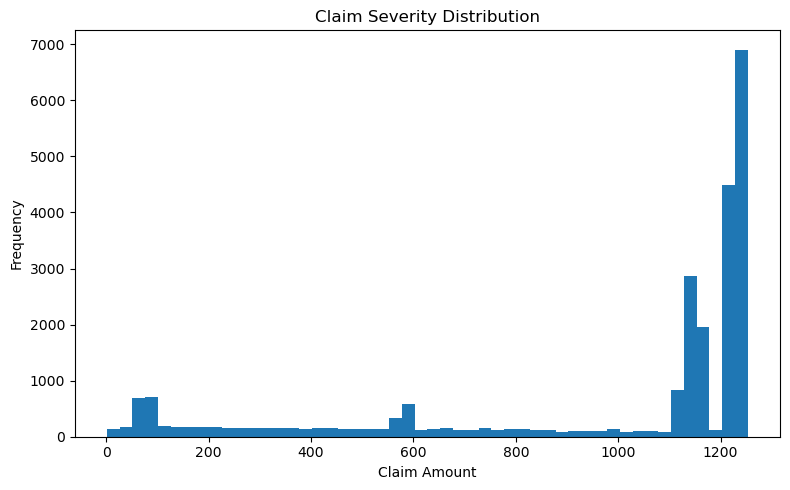

In [40]:
plt.figure(figsize=(8,5))
data.loc[data["claim_count"] > 0, "total_claim_amount"].plot(
    kind="hist", bins=50
)

plt.xlabel("Claim Amount")
plt.ylabel("Frequency")
plt.title("Claim Severity Distribution")

plt.tight_layout()
plt.savefig("./images/severity_distribution.png", dpi=300)
plt.show()

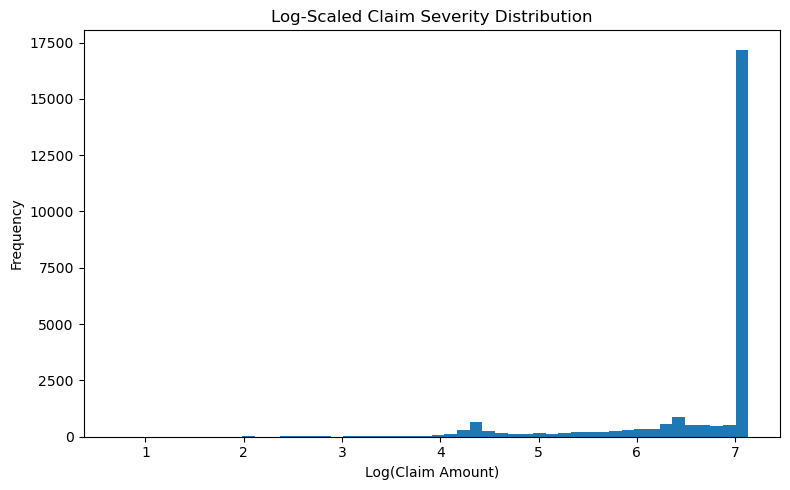

In [41]:
import numpy as np

plt.figure(figsize=(8,5))
np.log1p(
    data.loc[data["claim_count"] > 0, "total_claim_amount"]
).plot(kind="hist", bins=50)

plt.xlabel("Log(Claim Amount)")
plt.ylabel("Frequency")
plt.title("Log-Scaled Claim Severity Distribution")

plt.tight_layout()
plt.savefig("images/severity_distribution_log.png", dpi=300)
plt.show()

FEATURE ENGINEERING (FOR MODELING)

In [42]:
LEAK_COLS = [
    "claim_count",
    "total_claim_amount",
    "severity",
    "pure_premium",
    "frequency",
    "has_claim"
]

data_fe = data.drop(columns=[c for c in LEAK_COLS if c in data.columns])

In [43]:
data_fe["age_power_interaction"] = data_fe["DrivAge"] * data_fe["VehPower"]

In [44]:
data_fe["vehage_power_interaction"] = data_fe["VehAge"] * data_fe["VehPower"]

In [45]:
import numpy as np

data_fe["log_VehPower"] = np.log1p(data_fe["VehPower"])
data_fe["log_BonusMalus"] = np.log1p(data_fe["BonusMalus"])

In [46]:
data_fe = data_fe.drop(columns=["VehPower"])

In [47]:
data_fe = pd.get_dummies(
    data_fe,
    drop_first=True
)

In [48]:
X_freq = data_fe.copy()
y_freq = data["claim_count"]
exposure = data["Exposure"]

In [49]:
X_freq.shape, y_freq.shape

((678013, 52), (678013,))

In [50]:
mask = data["claim_count"] > 0

X_sev = data_fe.loc[mask].copy()
y_sev = data.loc[mask, "log_total_claim_amount"]

In [51]:
X_freq.describe().T

,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1.157951e+06,2.272152e+06,4.046274e+06,6.114330e+06
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,1.800000e-01,4.900000e-01,9.900000e-01,2.010000e+00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.000000e+00,6.000000e+00,1.100000e+01,1.000000e+02
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,3.400000e+01,4.400000e+01,5.500000e+01,1.000000e+02
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,5.000000e+01,5.000000e+01,6.400000e+01,2.300000e+02
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,9.200000e+01,3.930000e+02,1.658000e+03,2.700000e+04
Has_Claim,678013.0,3.678986e-02,1.882456e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
log_total_claim_amount,678013.0,2.452077e-01,1.265469e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,7.134356e+00
age_power_interaction,678013.0,2.945530e+02,1.342882e+02,72.000000,1.960000e+02,2.700000e+02,3.650000e+02,1.386000e+03


In [52]:
X_freq.corr().abs().max().sort_values(ascending=False).head()

IDpol               1.0
ClaimNb             1.0
Area_F              1.0
Region_Aquitaine    1.0
Region_Auvergne     1.0
dtype: float64

CLAIM FREQUENCY MODEL

In [53]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test, exp_train, exp_test = train_test_split(
    X_freq,
    y_freq,
    exposure,
    test_size=0.2,
    random_state=42
)

In [54]:
X_train.select_dtypes(exclude=["int64", "float64"]).columns

Index(['VehBrand_B10', 'VehBrand_B11', 'VehBrand_B12', 'VehBrand_B13',
       'VehBrand_B14', 'VehBrand_B2', 'VehBrand_B3', 'VehBrand_B4',
       'VehBrand_B5', 'VehBrand_B6', 'VehGas_Regular', 'Area_B', 'Area_C',
       'Area_D', 'Area_E', 'Area_F', 'Region_Aquitaine', 'Region_Auvergne',
       'Region_Basse-Normandie', 'Region_Bourgogne', 'Region_Bretagne',
       'Region_Centre', 'Region_Champagne-Ardenne', 'Region_Corse',
       'Region_Franche-Comte', 'Region_Haute-Normandie',
       'Region_Ile-de-France', 'Region_Languedoc-Roussillon',
       'Region_Limousin', 'Region_Midi-Pyrenees', 'Region_Nord-Pas-de-Calais',
       'Region_Pays-de-la-Loire', 'Region_Picardie', 'Region_Poitou-Charentes',
       'Region_Provence-Alpes-Cotes-D'Azur', 'Region_Rhone-Alpes',
       'DrivAgeBand_25-40', 'DrivAgeBand_40-60', 'DrivAgeBand_60+'],
      dtype='object')

In [55]:
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test  = X_test.apply(pd.to_numeric, errors="coerce")

In [56]:
exp_train = exp_train.astype(float)
exp_test  = exp_test.astype(float)

assert (exp_train > 0).all()
assert (exp_test > 0).all()

In [57]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train, has_constant="add")
X_test_sm  = sm.add_constant(X_test, has_constant="add")

In [58]:
bad_cols = X_train_sm.columns[X_train_sm.dtypes == "object"]
bad_cols

Index([], dtype='object')

In [59]:
X_train_sm.dtypes.value_counts()

bool       39
int64       8
float64     6
Name: count, dtype: int64

In [60]:
X_train_sm = X_train_sm.apply(lambda x: pd.to_numeric(x, errors="coerce")).astype(float)
X_test_sm  = X_test_sm.apply(lambda x: pd.to_numeric(x, errors="coerce")).astype(float)

In [61]:
X_train_sm.isna().sum().sort_values(ascending=False).head(10)

const                       0
Area_D                      0
Area_F                      0
Region_Aquitaine            0
Region_Auvergne             0
Region_Basse-Normandie      0
Region_Bourgogne            0
Region_Bretagne             0
Region_Centre               0
Region_Champagne-Ardenne    0
dtype: int64

In [62]:
X_train_sm = X_train_sm.fillna(X_train_sm.median())
X_test_sm  = X_test_sm.fillna(X_train_sm.median())

In [63]:
exp_train = pd.to_numeric(exp_train, errors="coerce").astype(float)
exp_test  = pd.to_numeric(exp_test, errors="coerce").astype(float)

print((exp_train <= 0).sum(), (exp_test <= 0).sum())

0 0


In [64]:
assert X_train_sm.dtypes.eq("float64").all()
assert np.isfinite(X_train_sm.values).all()
assert np.isfinite(np.log(exp_train)).all()

In [65]:
poisson_model = sm.GLM(
    y_train.values,
    X_train_sm.values,
    family=sm.families.Poisson(),
    offset=np.log(exp_train.values)
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542357
Model Family:                 Poisson   Df Model:                           52
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -21087.
Date:                Sat, 10 Jan 2026   Deviance:                       1786.0
Time:                        14:58:05   Pearson chi2:                 3.34e+03
No. Iterations:                    29   Pseudo R-squ. (CS):             0.2207
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -30.9962   1.13e+04     -0.003      0.9

In [66]:
y_pred_freq = poisson_model.predict(
    X_test_sm,
    offset=np.log(exp_test)
)

In [67]:
from sklearn.metrics import mean_poisson_deviance

poisson_dev = mean_poisson_deviance(y_test, y_pred_freq)
poisson_dev

0.0032180258060410492

In [68]:
freq_eval = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred_freq,
    "exposure": exp_test
})

freq_eval["decile"] = pd.qcut(freq_eval["predicted"], 10, duplicates="drop")

decile_freq = (
    freq_eval
    .groupby("decile")
    .apply(lambda x: x["actual"].sum() / x["exposure"].sum())
    .to_frame("actual_freq")
)

decile_freq["pred_freq"] = (
    freq_eval
    .groupby("decile")
    .apply(lambda x: x["predicted"].sum() / x["exposure"].sum())
)

decile_freq

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18936\1954795230.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("decile")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18936\1954795230.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["actual"].sum() / x["exposure"].sum())
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18936\1954795230.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to r

,actual_freq,pred_freq
decile,,
"(-0.000999999999999895, 2.63e-15]",0.000000,3.774139e-14
"(2.63e-15, 3.91e-15]",0.000000,3.457006e-14
"(3.91e-15, 5.43e-15]",0.000000,9.728438e-15
"(5.43e-15, 5.55e-15]",0.000000,5.819571e-15
"(5.55e-15, 5.7e-15]",0.000000,6.061804e-15
"(5.7e-15, 6.35e-15]",0.000000,9.414179e-15
"(6.35e-15, 6.93e-15]",0.000000,1.236035e-14
"(6.93e-15, 7.33e-15]",0.000000,1.354322e-14
"(7.33e-15, 7.65e-15]",0.000000,1.492268e-14


In [69]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [70]:
import xgboost
xgboost.__version__

'3.1.2'

In [71]:
from xgboost import XGBRegressor

gb_freq = XGBRegressor(
    objective="count:poisson",
    max_depth=4,
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

gb_freq.fit(X_train, y_train, sample_weight=exp_train)

,objective,'count:poisson'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [72]:
gb_pred_freq = gb_freq.predict(X_test)

In [73]:
gb_pred_freq

array([3.7163769e-05, 3.6306748e-05, 3.7758156e-05, ..., 3.5052748e-05,
       3.8410817e-05, 3.6582816e-05], shape=(135603,), dtype=float32)

In [74]:
LEAKAGE_COLS = [
    "Has_Claim",
    "log_total_claim_amount",
    "Exposure"
]

X_freq = X_freq.drop(columns=[c for c in LEAKAGE_COLS if c in X_freq.columns])

In [75]:
X_train, X_test, y_train, y_test, exp_train, exp_test = train_test_split(
    X_freq,
    y_freq,
    exposure,
    test_size=0.2,
    random_state=42
)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

In [76]:
X_train_sm.dtypes.value_counts()

bool       39
int64       7
float64     4
Name: count, dtype: int64

In [77]:
X_train_sm.dtypes[X_train_sm.dtypes != "float64"]

ClaimNb                               int64
VehAge                                int64
DrivAge                               int64
BonusMalus                            int64
Density                               int64
age_power_interaction                 int64
vehage_power_interaction              int64
VehBrand_B10                           bool
VehBrand_B11                           bool
VehBrand_B12                           bool
VehBrand_B13                           bool
VehBrand_B14                           bool
VehBrand_B2                            bool
VehBrand_B3                            bool
VehBrand_B4                            bool
VehBrand_B5                            bool
VehBrand_B6                            bool
VehGas_Regular                         bool
Area_B                                 bool
Area_C                                 bool
Area_D                                 bool
Area_E                                 bool
Area_F                          

In [78]:
X_train_sm = X_train_sm.astype(float)
X_test_sm  = X_test_sm.astype(float)

y_train = y_train.astype(float)
exp_train = exp_train.astype(float)

In [79]:
poisson_model = sm.GLM(
    y_train,
    X_train_sm,
    family=sm.families.Poisson(),
    offset=np.log(exp_train)
).fit()

In [80]:
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542360
Model Family:                 Poisson   Df Model:                           49
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -70080.
Date:                Sat, 10 Jan 2026   Deviance:                       99773.
Time:                        14:59:02   Pearson chi2:                 8.84e+05
No. Iterations:                    35   Pseudo R-squ. (CS):            0.06636
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

In [81]:
coef = pd.Series(
    poisson_model.params,
    index=X_train_sm.columns
).sort_values(ascending=False)

coef.head(10)

log_BonusMalus        3.636983
ClaimNb               0.913212
Area_F                0.626671
log_VehPower          0.554158
Area_E                0.546486
Region_Limousin       0.427974
Area_C                0.422915
Area_D                0.336087
Area_B                0.335042
Region_Rhone-Alpes    0.320830
dtype: float64

In [82]:
poisson_model.params.sort_values(ascending=False).head(10)

log_BonusMalus        3.636983
ClaimNb               0.913212
Area_F                0.626671
log_VehPower          0.554158
Area_E                0.546486
Region_Limousin       0.427974
Area_C                0.422915
Area_D                0.336087
Area_B                0.335042
Region_Rhone-Alpes    0.320830
dtype: float64

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18936\955383469.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = freq_eval.groupby("decile").apply(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18936\955383469.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  calib = freq_eval.groupby("decile").apply(


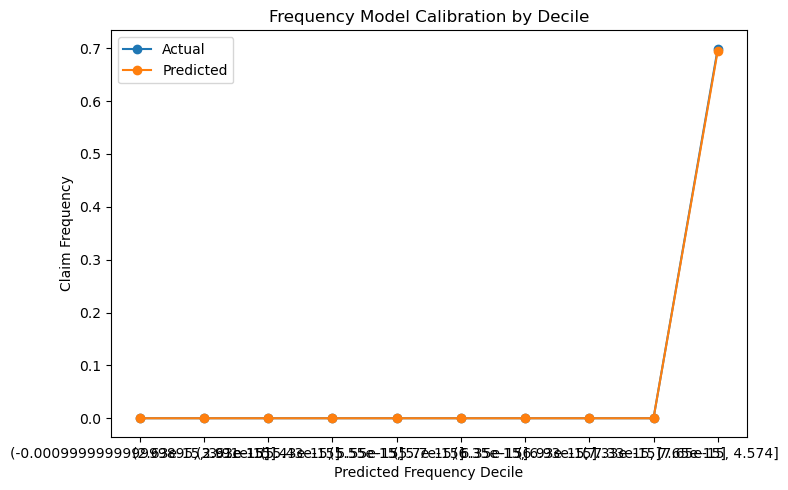

In [83]:
freq_eval = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred_freq,
    "exposure": exp_test
})

freq_eval["decile"] = pd.qcut(
    freq_eval["predicted"], 10, duplicates="drop"
)

calib = freq_eval.groupby("decile").apply(
    lambda x: pd.Series({
        "actual_freq": x["actual"].sum() / x["exposure"].sum(),
        "pred_freq": x["predicted"].sum() / x["exposure"].sum()
    })
)

plt.figure(figsize=(8,5))
plt.plot(calib.index.astype(str), calib["actual_freq"], marker="o", label="Actual")
plt.plot(calib.index.astype(str), calib["pred_freq"], marker="o", label="Predicted")

plt.xlabel("Predicted Frequency Decile")
plt.ylabel("Claim Frequency")
plt.title("Frequency Model Calibration by Decile")
plt.legend()

plt.tight_layout()
plt.savefig("images/frequency_calibration.png", dpi=300)
plt.show()

SEVERITY MODEL (CLAIM AMOUNT MODEL)

In [84]:
sev_mask = y_freq > 0   # or data["claim_count"] > 0

X_sev = X_freq.loc[sev_mask].copy()
y_sev = data.loc[sev_mask, "log_total_claim_amount"]

In [85]:
FREQ_ONLY_COLS = [
    "BonusMalus", 
    "log_BonusMalus"
]

X_sev = X_sev.drop(columns=[c for c in FREQ_ONLY_COLS if c in X_sev.columns])

In [86]:
from sklearn.model_selection import train_test_split

X_sev_train, X_sev_test, y_sev_train, y_sev_test = train_test_split(
    X_sev,
    y_sev,
    test_size=0.2,
    random_state=42
)

In [87]:
import statsmodels.api as sm

X_sev_train_sm = sm.add_constant(X_sev_train).astype(float)
X_sev_test_sm  = sm.add_constant(X_sev_test).astype(float)

sev_model = sm.OLS(
    y_sev_train.astype(float),
    X_sev_train_sm
).fit()

print(sev_model.summary())

                              OLS Regression Results                              
Dep. Variable:     log_total_claim_amount   R-squared:                       0.028
Model:                                OLS   Adj. R-squared:                  0.025
Method:                     Least Squares   F-statistic:                     12.08
Date:                    Sat, 10 Jan 2026   Prob (F-statistic):           4.42e-89
Time:                            14:59:05   Log-Likelihood:                -25061.
No. Observations:                   19955   AIC:                         5.022e+04
Df Residuals:                       19907   BIC:                         5.060e+04
Df Model:                              47                                         
Covariance Type:                nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [88]:
y_sev_pred_log = sev_model.predict(X_sev_test_sm)

In [89]:
import numpy as np

y_sev_pred = np.expm1(y_sev_pred_log)
y_sev_actual = np.expm1(y_sev_test)

In [90]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mae = mean_absolute_error(y_sev_actual, y_sev_pred)
rmse = np.sqrt(mean_squared_error(y_sev_actual, y_sev_pred))

mae, rmse

(398.7412989365289, np.float64(432.06985735759247))

In [91]:
sev_eval = pd.DataFrame({
    "actual": y_sev_actual,
    "predicted": y_sev_pred
})

sev_eval["decile"] = pd.qcut(sev_eval["predicted"], 10, duplicates="drop")

sev_deciles = sev_eval.groupby("decile").mean()
sev_deciles

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18936\4182103475.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sev_deciles = sev_eval.groupby("decile").mean()


,actual,predicted
decile,,
"(559.875, 675.567]",897.223234,651.244702
"(675.567, 701.301]",937.412838,689.142394
"(701.301, 722.017]",892.499582,712.200700
"(722.017, 740.825]",918.981824,731.180644
"(740.825, 761.666]",918.406142,751.099160
"(761.666, 784.403]",975.660883,772.608906
"(784.403, 809.935]",989.228284,796.428083
"(809.935, 850.245]",1000.324527,828.012148
"(850.245, 937.107]",1031.950684,889.758683


In [92]:
sev_coef = pd.Series(
    sev_model.params,
    index=X_sev_train_sm.columns
).sort_values(ascending=False)

sev_coef.head(10)
sev_coef.tail(10)

VehBrand_B10        -0.001270
VehBrand_B13        -0.003147
Area_B              -0.009384
VehGas_Regular      -0.010445
VehBrand_B4         -0.040453
VehBrand_B5         -0.043085
DrivAgeBand_60+     -0.050983
DrivAgeBand_25-40   -0.079781
DrivAgeBand_40-60   -0.080012
VehBrand_B11        -0.108291
dtype: float64

COMBINE FREQUENCY + SEVERITY → RISK SCORE

In [93]:
# Prepare full feature matrix
X_all_freq = sm.add_constant(X_freq).astype(float)

# Predict expected claim frequency
pred_freq = poisson_model.predict(
    X_all_freq,
    offset=np.log(exposure)
)

In [94]:
pred_freq.describe()

count    678013.000000
mean          0.038268
std           1.234066
min           0.000003
25%           0.008431
50%           0.025904
75%           0.046595
max         822.594777
Name: Exposure, dtype: float64

In [95]:
# Prepare full severity feature matrix
X_all_sev = X_freq.drop(columns=[c for c in FREQ_ONLY_COLS if c in X_freq.columns])

X_all_sev_sm = sm.add_constant(X_all_sev).astype(float)

# Predict log severity
pred_log_sev = sev_model.predict(X_all_sev_sm)

# Convert back to currency scale
pred_sev = np.expm1(pred_log_sev)

In [96]:
pred_sev.describe()

count    678013.000000
mean        620.982900
std         106.083951
min         403.464016
25%         556.339852
50%         599.202119
75%         671.107213
max       41935.769644
dtype: float64

In [97]:
expected_loss = pred_freq * pred_sev

In [98]:
risk_output = data.copy()

risk_output["predicted_frequency"] = pred_freq
risk_output["predicted_severity"] = pred_sev
risk_output["expected_annual_loss"] = expected_loss

In [99]:
risk_output["risk_score"] = (
    risk_output["expected_annual_loss"]
    .rank(pct=True) * 100
)

In [100]:
risk_output["risk_band"] = pd.cut(
    risk_output["risk_score"],
    bins=[0, 30, 70, 100],
    labels=["Low", "Medium", "High"]
)

In [101]:
risk_output["decile"] = pd.qcut(
    risk_output["expected_annual_loss"],
    10,
    duplicates="drop"
)

decile_check = (
    risk_output
    .groupby("decile")
    .agg(
        avg_expected_loss=("expected_annual_loss", "mean"),
        actual_loss=("total_claim_amount", "mean"),
        exposure=("Exposure", "sum")
    )
)

decile_check

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18936\1037516240.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("decile")


,avg_expected_loss,actual_loss,exposure
decile,,,
"(0.00067, 1.454]",0.611327,4.014314,13254.801941
"(1.454, 3.637]",2.501186,7.714041,7544.467105
"(3.637, 7.02]",5.230325,6.416028,11712.168219
"(7.02, 11.414]",9.162956,7.541214,22442.428197
"(11.414, 15.88]",13.664006,6.152157,36875.790000
"(15.88, 20.281]",18.073356,6.156647,46910.170000
"(20.281, 25.169]",22.659704,7.543035,52705.740000
"(25.169, 31.493]",28.121129,10.387230,55913.990000
"(31.493, 44.996]",36.951222,24.471331,55712.500000


In [102]:
risk_output = pd.DataFrame({
    "policy_id": data["IDpol"],
    "predicted_frequency": risk_output["predicted_frequency"],
    "predicted_severity": risk_output["predicted_severity"],
    "expected_annual_loss": risk_output["expected_annual_loss"],
    "risk_score": risk_output["risk_score"],
    "risk_band": risk_output["risk_band"]
})

In [103]:
risk_output.to_csv("./Output/insurance_risk_scores.csv", index=False)

In [104]:
risk_validation = pd.DataFrame({
    "policy_id": data["IDpol"],                       # or your policy ID column
    "expected_annual_loss": risk_output["expected_annual_loss"],
    "actual_claim_count": data["claim_count"],
    "actual_total_claim_amount": data["total_claim_amount"]
})

In [105]:
risk_validation["risk_decile"] = (
    pd.qcut(
        risk_validation["expected_annual_loss"],
        10,
        labels=False,
        duplicates="drop"
    ) + 1
)

In [106]:
risk_validation["loss_ratio"] = (
    risk_validation["actual_total_claim_amount"] /
    risk_validation["expected_annual_loss"]
)

risk_validation["loss_ratio"] = risk_validation["loss_ratio"].replace(
    [np.inf, -np.inf], np.nan
)

In [107]:
risk_validation.to_csv("./Output/insurance_risk_validation.csv",index=False)

In [108]:
risk_validation.head()

,policy_id,expected_annual_loss,actual_claim_count,actual_total_claim_amount,risk_decile,loss_ratio
0,1.0,9.406283,0.0,0.0,4,0.0
1,3.0,72.428385,0.0,0.0,10,0.0
2,5.0,79.375221,0.0,0.0,10,0.0
3,10.0,10.014902,0.0,0.0,4,0.0
4,11.0,93.472425,0.0,0.0,10,0.0


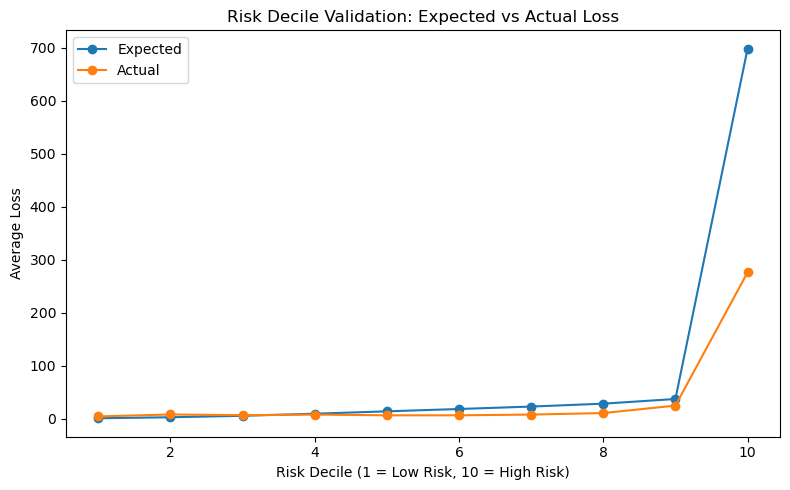

In [109]:
decile_check = risk_validation.groupby("risk_decile").agg(
    expected_loss=("expected_annual_loss", "mean"),
    actual_loss=("actual_total_claim_amount", "mean")
)

plt.figure(figsize=(8,5))
plt.plot(decile_check.index, decile_check["expected_loss"], marker="o", label="Expected")
plt.plot(decile_check.index, decile_check["actual_loss"], marker="o", label="Actual")

plt.xlabel("Risk Decile (1 = Low Risk, 10 = High Risk)")
plt.ylabel("Average Loss")
plt.title("Risk Decile Validation: Expected vs Actual Loss")
plt.legend()

plt.tight_layout()
plt.savefig("images/risk_decile_validation.png", dpi=300)
plt.show()

EXPLAINABILITY & FEATURE IMPACT

In [110]:
freq_coef = pd.Series(
    poisson_model.params,
    index=X_train_sm.columns
).sort_values(ascending=False)

freq_coef

log_BonusMalus                        3.636983e+00
ClaimNb                               9.132118e-01
Area_F                                6.266714e-01
log_VehPower                          5.541577e-01
Area_E                                5.464862e-01
Region_Limousin                       4.279737e-01
Area_C                                4.229152e-01
Area_D                                3.360874e-01
Area_B                                3.350416e-01
Region_Rhone-Alpes                    3.208300e-01
Region_Corse                          2.791214e-01
Region_Provence-Alpes-Cotes-D'Azur    2.437997e-01
VehBrand_B5                           2.226917e-01
Region_Picardie                       2.180706e-01
Region_Poitou-Charentes               2.160690e-01
Region_Pays-de-la-Loire               1.816813e-01
VehBrand_B6                           1.809937e-01
Region_Aquitaine                      1.667528e-01
Region_Bourgogne                      1.659636e-01
VehBrand_B11                   

In [111]:
sev_coef = pd.Series(
    sev_model.params,
    index=X_sev_train_sm.columns
).sort_values(ascending=False)

sev_coef

const                                 5.883864e+00
Region_Franche-Comte                  2.991160e-01
ClaimNb                               2.672894e-01
Region_Corse                          2.230333e-01
VehBrand_B12                          1.600623e-01
Region_Limousin                       1.557416e-01
VehBrand_B14                          1.295071e-01
log_VehPower                          1.281386e-01
Region_Auvergne                       1.223716e-01
Region_Bourgogne                      1.187753e-01
Region_Bretagne                       1.186573e-01
Region_Poitou-Charentes               1.170534e-01
Region_Nord-Pas-de-Calais             1.145645e-01
Region_Haute-Normandie                1.138244e-01
Region_Aquitaine                      1.131658e-01
Region_Basse-Normandie                1.038831e-01
Region_Ile-de-France                  9.067263e-02
Region_Provence-Alpes-Cotes-D'Azur    8.989459e-02
Region_Pays-de-la-Loire               7.488981e-02
Area_F                         

In [112]:
freq_importance = freq_coef.abs().sort_values(ascending=False)
freq_importance.head(10)

const                          17.954756
log_BonusMalus                  3.636983
Region_Languedoc-Roussillon     3.189960
ClaimNb                         0.913212
Area_F                          0.626671
log_VehPower                    0.554158
Area_E                          0.546486
Region_Limousin                 0.427974
Area_C                          0.422915
Area_D                          0.336087
dtype: float64

In [113]:
sev_importance = sev_coef.abs().sort_values(ascending=False)
sev_importance.head(10)

const                   5.883864
Region_Franche-Comte    0.299116
ClaimNb                 0.267289
Region_Corse            0.223033
VehBrand_B12            0.160062
Region_Limousin         0.155742
VehBrand_B14            0.129507
log_VehPower            0.128139
Region_Auvergne         0.122372
Region_Bourgogne        0.118775
dtype: float64